##Installing Required Library

In [ ]:
!pip install opendatasets

##Importing Libraries

In [ ]:
import opendatasets as od
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Downloading Dataset

In [ ]:
od.download("https://www.kaggle.com/datasets/sukhmandeepsinghbrar/car-price-prediction-dataset/data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ibrohimkhudoyberdi
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/sukhmandeepsinghbrar/car-price-prediction-dataset


100%|██████████| 141k/141k [00:00<00:00, 12.9MB/s]

##Loading Dataset

In [ ]:
df = pd.read_csv("/content/car-price-prediction-dataset/cardekho.csv")
print(df.shape)
df.head(20)

(8128, 12)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0
5,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14,1197.0,81.86,5.0
6,Maruti Wagon R LXI DUO BSIII,2007,96000,175000,LPG,Individual,Manual,First Owner,17.30,1061.0,57.5,5.0
7,Maruti 800 DX BSII,2001,45000,5000,Petrol,Individual,Manual,Second Owner,16.10,796.0,37,4.0
8,Toyota Etios VXD,2011,350000,90000,Diesel,Individual,Manual,First Owner,23.59,1364.0,67.1,5.0
9,Ford Figo Diesel Celebration Edition,2013,200000,169000,Diesel,Individual,Manual,First Owner,20.00,1399.0,68.1,5.0


##Missing Value Analysis

In [ ]:
df.isnull().sum().sort_values(ascending=False).head()

,0
seats,221
mileage(km/ltr/kg),221
engine,221
max_power,215
km_driven,0


##Missing Value Percentage

In [ ]:
miss = (df.isnull().sum() / len(df) * 100).round(2)
miss[miss > 0].sort_values(ascending=False)

,0
mileage(km/ltr/kg),2.72
engine,2.72
seats,2.72
max_power,2.65


##Missing Value Heatmap

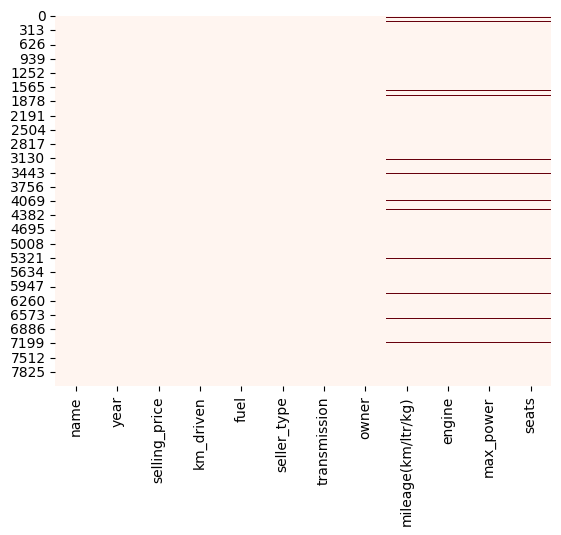

In [ ]:
sns.heatmap(df.isnull(), cbar=False, cmap="Reds")
plt.show()

The `heatmap` visualizes the distribution of missing values across the dataset. This helps identify patterns and concentrations of incomplete data. Areas with more red indicate features requiring cleaning or imputation.

##Cleaning Owner Column

In [ ]:
df['owner'] = df['owner'].str.replace(' Owner', '', regex=False)


##Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


##Converting max_power to Numeric

In [ ]:
df['max_power'] = (
    pd.to_numeric(
        df['max_power'].astype(str).str.replace(r"[^\d.]", "", regex=True),
        errors='coerce'
    )
)

##Missing Value Imputation

In [ ]:
cat_all = df.select_dtypes(include='object').columns
df[cat_all] = df[cat_all].fillna('None')

num = df.select_dtypes(include='number').columns
df[num] = df[num].fillna(df[num].median())

print(df.isnull().sum().sum())

0


##Duplicate Removal

In [ ]:
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

1202
0


##Data Type Summary

In [ ]:
df.dtypes.value_counts()

,count
object,5
float64,4
int64,3


##Outlier Detection: selling_price

In [ ]:
Q1 = df['selling_price'].quantile(0.25)
Q3 = df['selling_price'].quantile(0.75)
IQR = Q3 - Q1

mask = (df['selling_price'] >= Q1 - 1.5 * IQR) & (df['selling_price'] <= Q3 + 1.5 * IQR)
df_clean_data = df[mask]

In [ ]:
print(df_clean_data.shape)
df_clean_data.head(15)

(6598, 12)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First,23.40,1248.0,74.00,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third,17.70,1497.0,78.00,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First,23.00,1396.0,90.00,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First,16.10,1298.0,88.20,5.0
5,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First,20.14,1197.0,81.86,5.0
6,Maruti Wagon R LXI DUO BSIII,2007,96000,175000,LPG,Individual,Manual,First,17.30,1061.0,57.50,5.0
7,Maruti 800 DX BSII,2001,45000,5000,Petrol,Individual,Manual,Second,16.10,796.0,37.00,4.0
8,Toyota Etios VXD,2011,350000,90000,Diesel,Individual,Manual,First,23.59,1364.0,67.10,5.0
9,Ford Figo Diesel Celebration Edition,2013,200000,169000,Diesel,Individual,Manual,First,20.00,1399.0,68.10,5.0


##Outlier Visualization: selling_price

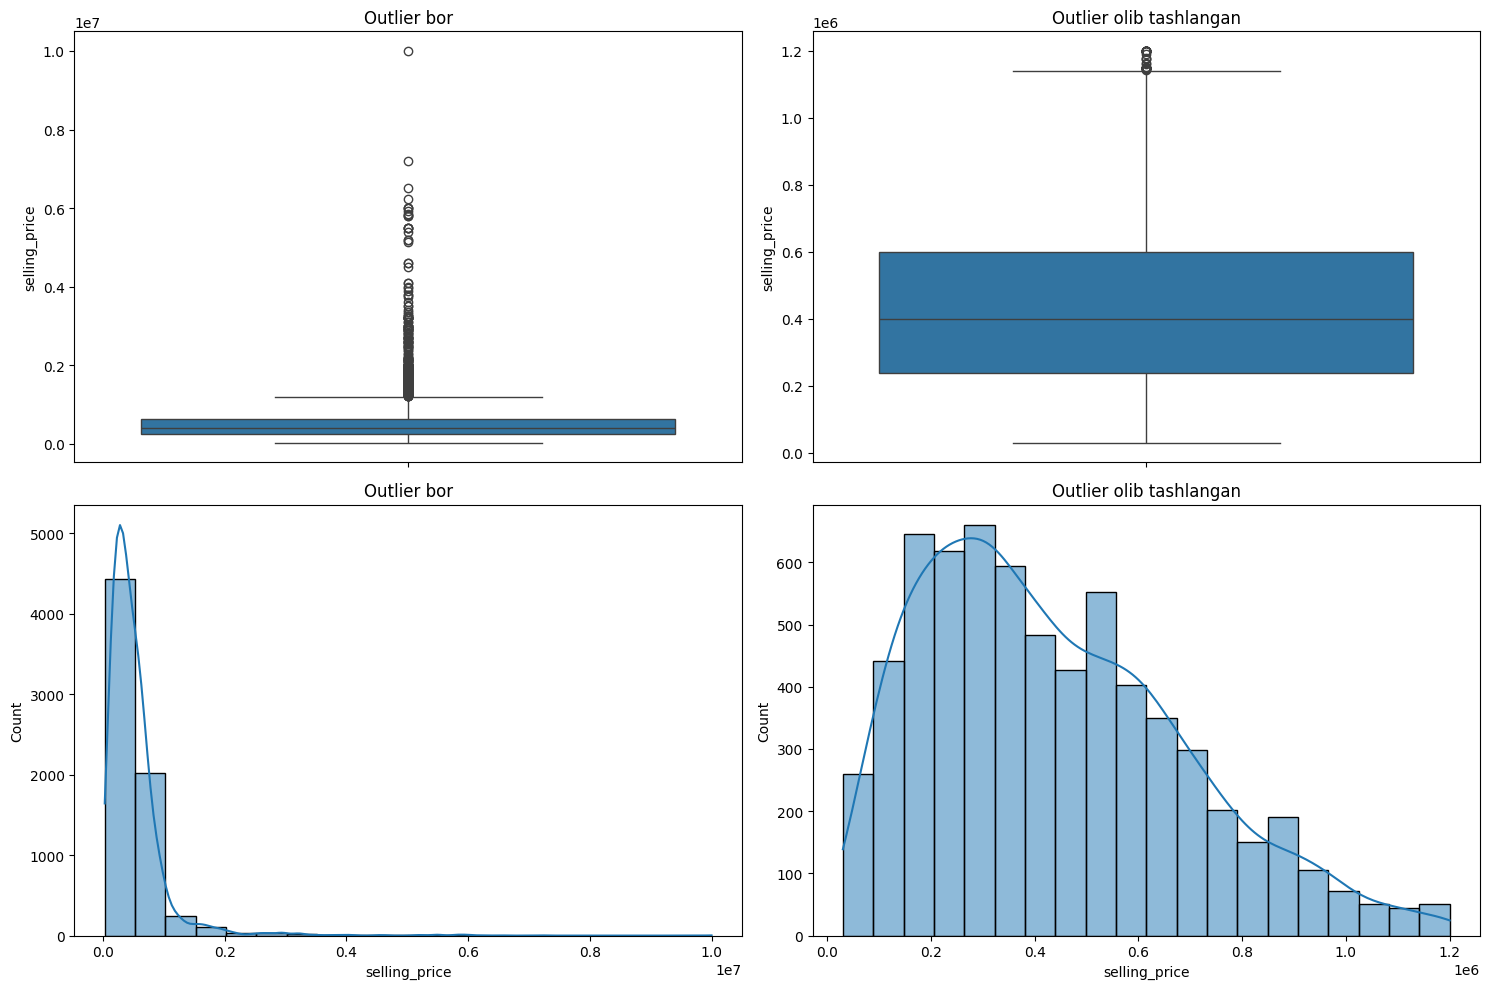

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

sns.boxplot(data=df, y='selling_price', ax=axes[0,0])
axes[0,0].set_title('Outlier bor')

sns.boxplot(data=df_clean_data, y='selling_price', ax=axes[0,1])
axes[0,1].set_title('Outlier olib tashlangan')

sns.histplot(data=df, x='selling_price', bins=20, kde="reg", ax=axes[1,0])
axes[1,0].set_title('Outlier bor')

sns.histplot(data=df_clean_data, bins=20, x='selling_price', kde="reg", ax=axes[1,1])
axes[1,1].set_title("Outlier olib tashlangan")

plt.tight_layout()
plt.show()

The `boxplots` compare selling price distributions before and after outlier treatment. The reduction of extreme values results in a more representative dataset.
The `histograms` show how the target variable distribution changes after removing abnormal observations. The cleaned distribution becomes more balanced and suitable for modeling.



##Statistical Summary

In [ ]:
df_clean_data.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats
count,6598.000000,6.598000e+03,6.598000e+03,6598.000000,6598.000000,6598.000000,6598.000000
mean,2013.260988,4.337417e+05,7.530782e+04,19.662414,1385.002273,83.650501,5.396181
std,4.087911,2.500576e+05,5.898717e+04,3.897694,451.936438,25.207451,0.959099
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,2.000000
25%,2011.000000,2.385000e+05,4.000000e+04,17.010000,1197.000000,67.100000,5.000000
50%,2014.000000,3.990000e+05,7.000000e+04,19.620000,1248.000000,81.830000,5.000000
75%,2016.000000,6.000000e+05,1.000000e+05,22.540000,1497.000000,94.930000,5.000000
max,2020.000000,1.200000e+06,2.360457e+06,33.440000,3498.000000,272.000000,14.000000


##Downloading Cleaned Dataset

In [ ]:
from google.colab import files
df_clean_data.to_csv('df_clean_data.csv', index=False)
files.download('df_clean_data.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**Exploratory Data Analysis (EDA)**

##Loading Cleaned Dataset

In [ ]:
df = pd.read_csv("/content/df_clean_data.csv")

##Dataset Overview

In [ ]:
print(df.shape)
print(df.info())
print(df.describe())

(6598, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6598 entries, 0 to 6597
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                6598 non-null   object 
 1   year                6598 non-null   int64  
 2   selling_price       6598 non-null   int64  
 3   km_driven           6598 non-null   int64  
 4   fuel                6598 non-null   object 
 5   seller_type         6598 non-null   object 
 6   transmission        6598 non-null   object 
 7   owner               6598 non-null   object 
 8   mileage(km/ltr/kg)  6598 non-null   float64
 9   engine              6598 non-null   float64
 10  max_power           6598 non-null   float64
 11  seats               6598 non-null   float64
dtypes: float64(4), int64(3), object(5)
memory usage: 618.7+ KB
None
              year  selling_price     km_driven  mileage(km/ltr/kg)  \
count  6598.000000   6.598000e+03  6.598000e+03         

##Target Variable Distribution

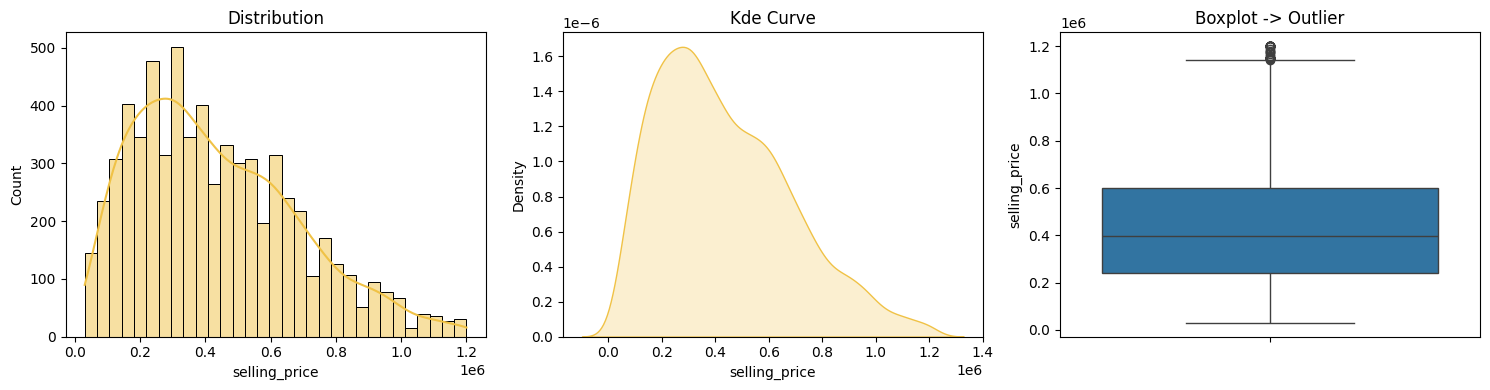

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

sns.histplot(df['selling_price'], color='#f0c246', kde=True, ax=axes[0])
axes[0].set_title('Distribution')

sns.kdeplot(df['selling_price'], color='#f0c246', fill=True, ax=axes[1])
axes[1].set_title('Kde Curve')

sns.boxplot(y=df['selling_price'], ax=axes[2])
axes[2].set_title('Boxplot -> Outlier')

plt.tight_layout()
plt.show()

The `histogram` visualizes the distribution of vehicle selling prices. The `boxplot` highlights remaining outliers, while the `kdeplot` helps evaluate normality and skewness.

##Calculate Skewness

In [ ]:
skew_value = df["selling_price"].skew()

print("Skewness:", skew_value)

if skew_value > 0.5:
    print("Right-skewed")
elif skew_value < -0.5:
    print("Left-skewed")
else:
    print("Approximately normal/symmetric")


Skewness: 0.6728571017362552
Right-skewed


In [ ]:
# check skewness of target
skew = df["selling_price"].skew()

# log transform target if skewed
if skew > 1:
    df["selling_price"] = np.log1p(df["selling_price"])

##Log Transformation

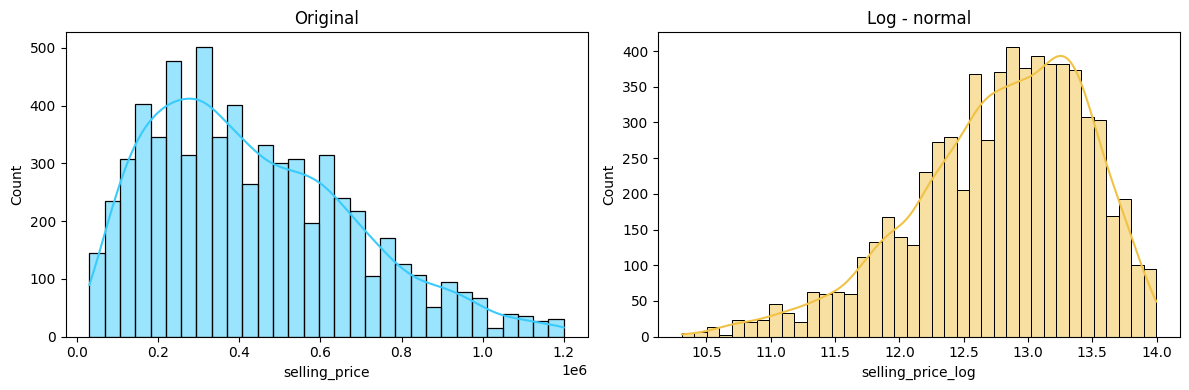

In [ ]:
df['selling_price_log'] = np.log1p(df['selling_price'])

fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.histplot(df['selling_price'], color='#38cbfc', kde=True, ax=axes[0])
axes[0].set_title('Original')

sns.histplot(df['selling_price_log'], color='#f0c246', kde=True, ax=axes[1])
axes[1].set_title('Log - normal')

plt.tight_layout()
plt.show()

The comparison of original and log-transformed selling prices demonstrates how logarithmic transformation reduces skewness and improves distribution symmetry.

##Correlation Analysis

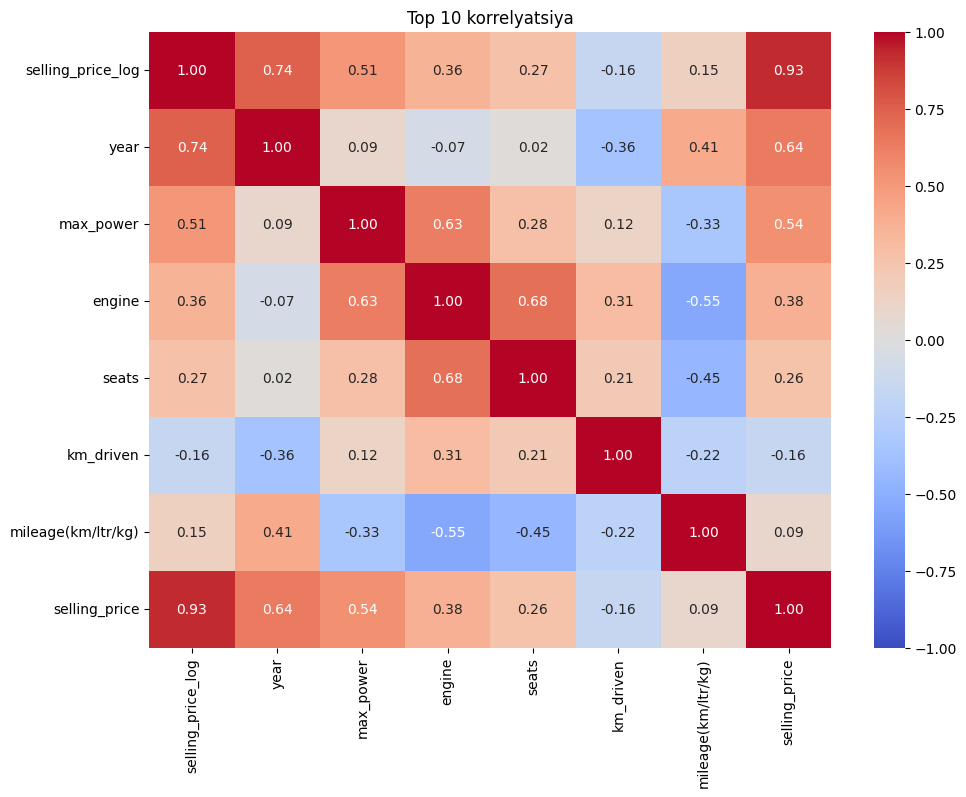

In [ ]:
num_df = df.select_dtypes(include='number')
corr = num_df.corr()


top10 = corr['selling_price'].drop('selling_price').abs().sort_values(ascending=False).head(10).index
top_cols = list(top10) + ['selling_price']


#Heatmap
plt.figure(figsize=(11,8))

sns.heatmap(
    corr[top_cols].loc[top_cols], annot=True, fmt ='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1
)
plt.title('Top 10 korrelyatsiya')
plt.show()

The correlation `heatmap` illustrates relationships among numerical features. Strong positive and negative correlations help identify variables that influence selling price.

###Insight

Features such as max_power, engine size, and vehicle year show stronger relationships with selling price compared to other variables.

##Fuel Type Analysis

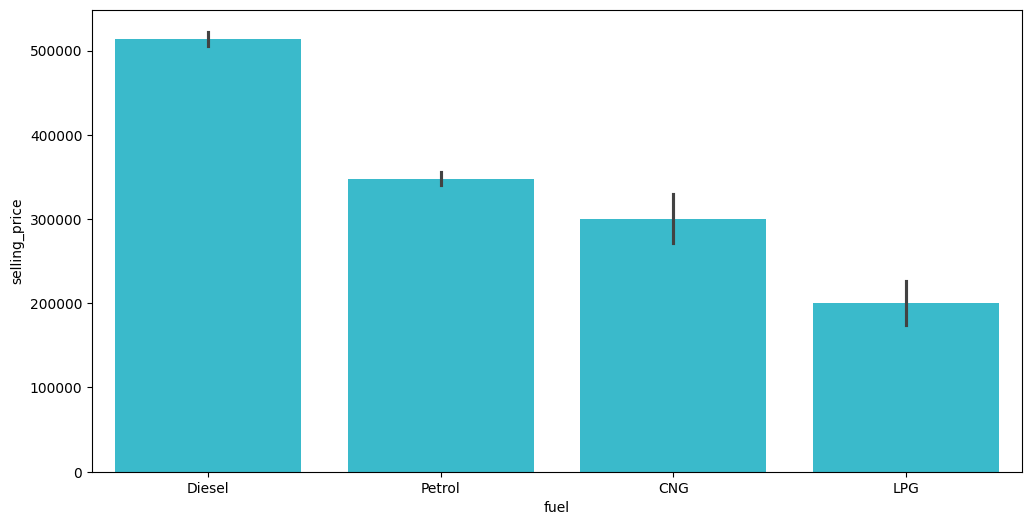

In [ ]:
 fuel_col = df.groupby('fuel')['selling_price'].mean().sort_values(ascending=False)

 plt.figure(figsize=(12,6))
 sns.barplot(data=df, x='fuel', y='selling_price',
             order=fuel_col.index, color='#22cce3')
 plt.show()


The `barplot` compares average selling prices across different fuel categories. This helps identify which fuel types tend to have higher market values.

##Max Power vs Selling Price

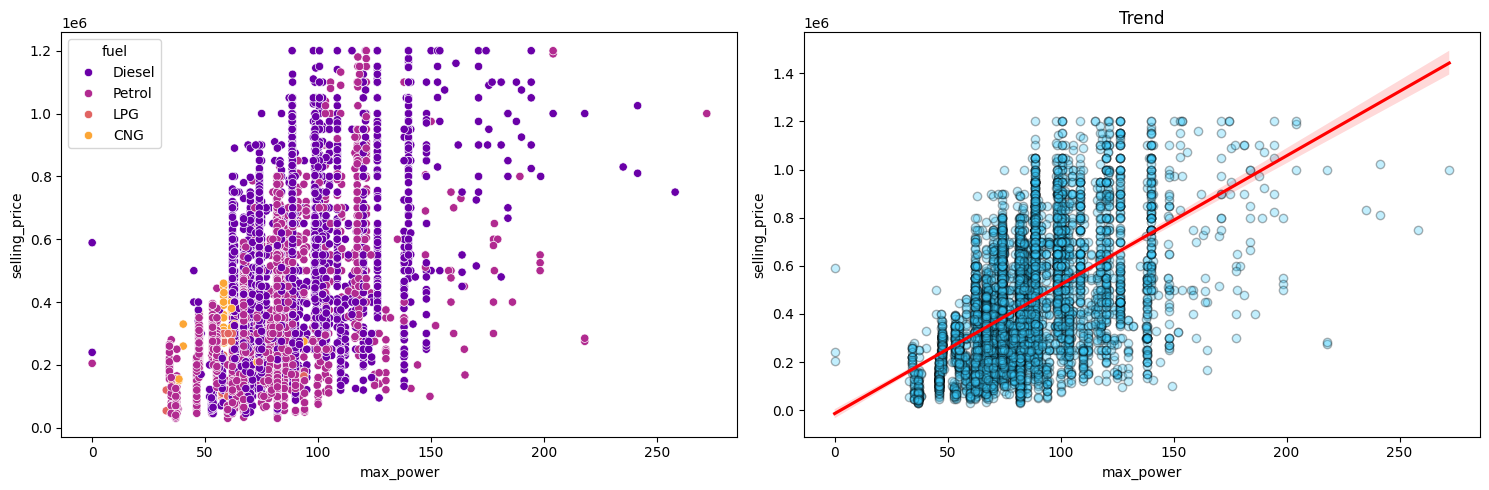

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

# 1. Scatter
sns.scatterplot(
    data=df, x='max_power', y='selling_price',
    hue='fuel', ax=axes[0], palette='plasma'
)

# 2. Regplot
sns.regplot(
    data=df, x='max_power', y='selling_price',
    scatter_kws={'alpha': 0.3, 'color':"#38cbfc", 'edgecolor':'black'},
    line_kws={'color':'red'},ax=axes[1]
)
axes[1].set_title('Trend')
plt.tight_layout()
plt.show()

The `scatterplot` illustrates the relationship between engine power and selling price. A positive trend suggests that more powerful vehicles generally command higher prices. The `regplot` line quantifies the overall trend and provides evidence of a positive association between engine power and vehicle value.

##Decade Trend Analysis

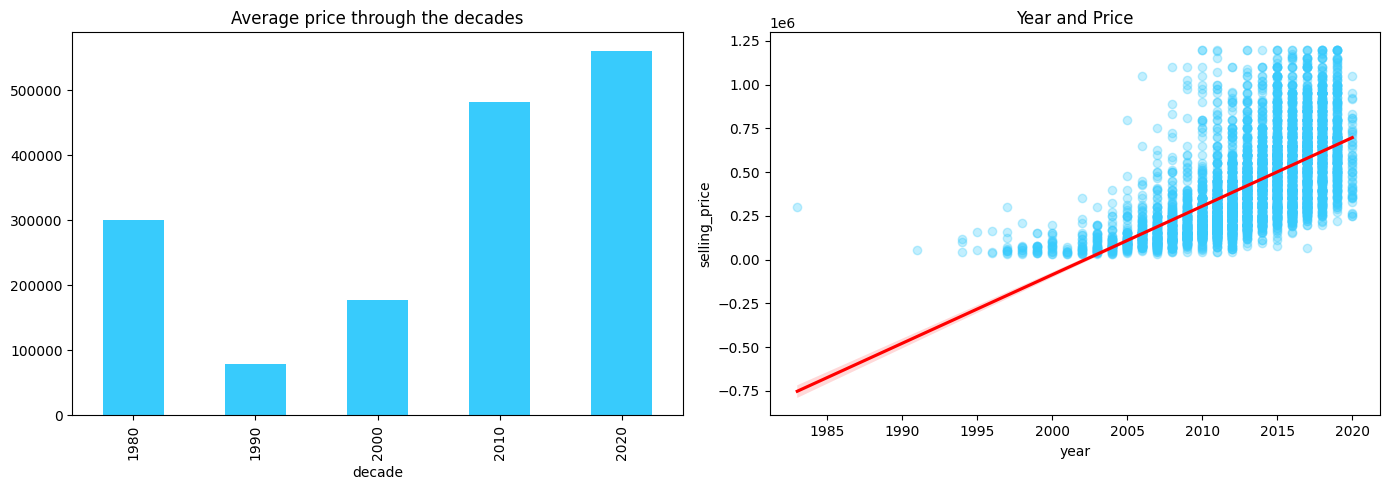

In [ ]:
df['decade'] = (df['year'] // 10) * 10

decade_avg = df.groupby('decade')['selling_price'].mean()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Decade barplot
decade_avg.plot(kind='bar', ax=axes[0], color='#38cbfc')
axes[0].set_title('Average price through the decades')


# 2. Scatter: Year vs Selling Price
sns.regplot(
    data=df, x='year', y='selling_price',
    scatter_kws={'alpha':0.3, 'color': '#38cbfc'},
    line_kws={'color': 'red'}, ax=axes[1]
)
axes[1].set_title('Year and Price')

plt.tight_layout()
plt.show()

The line chart shows how average vehicle selling prices have evolved across different decades. The bar chart provides a direct comparison of average prices between decades, highlighting long-term market trends.

##Pairplot Analysis

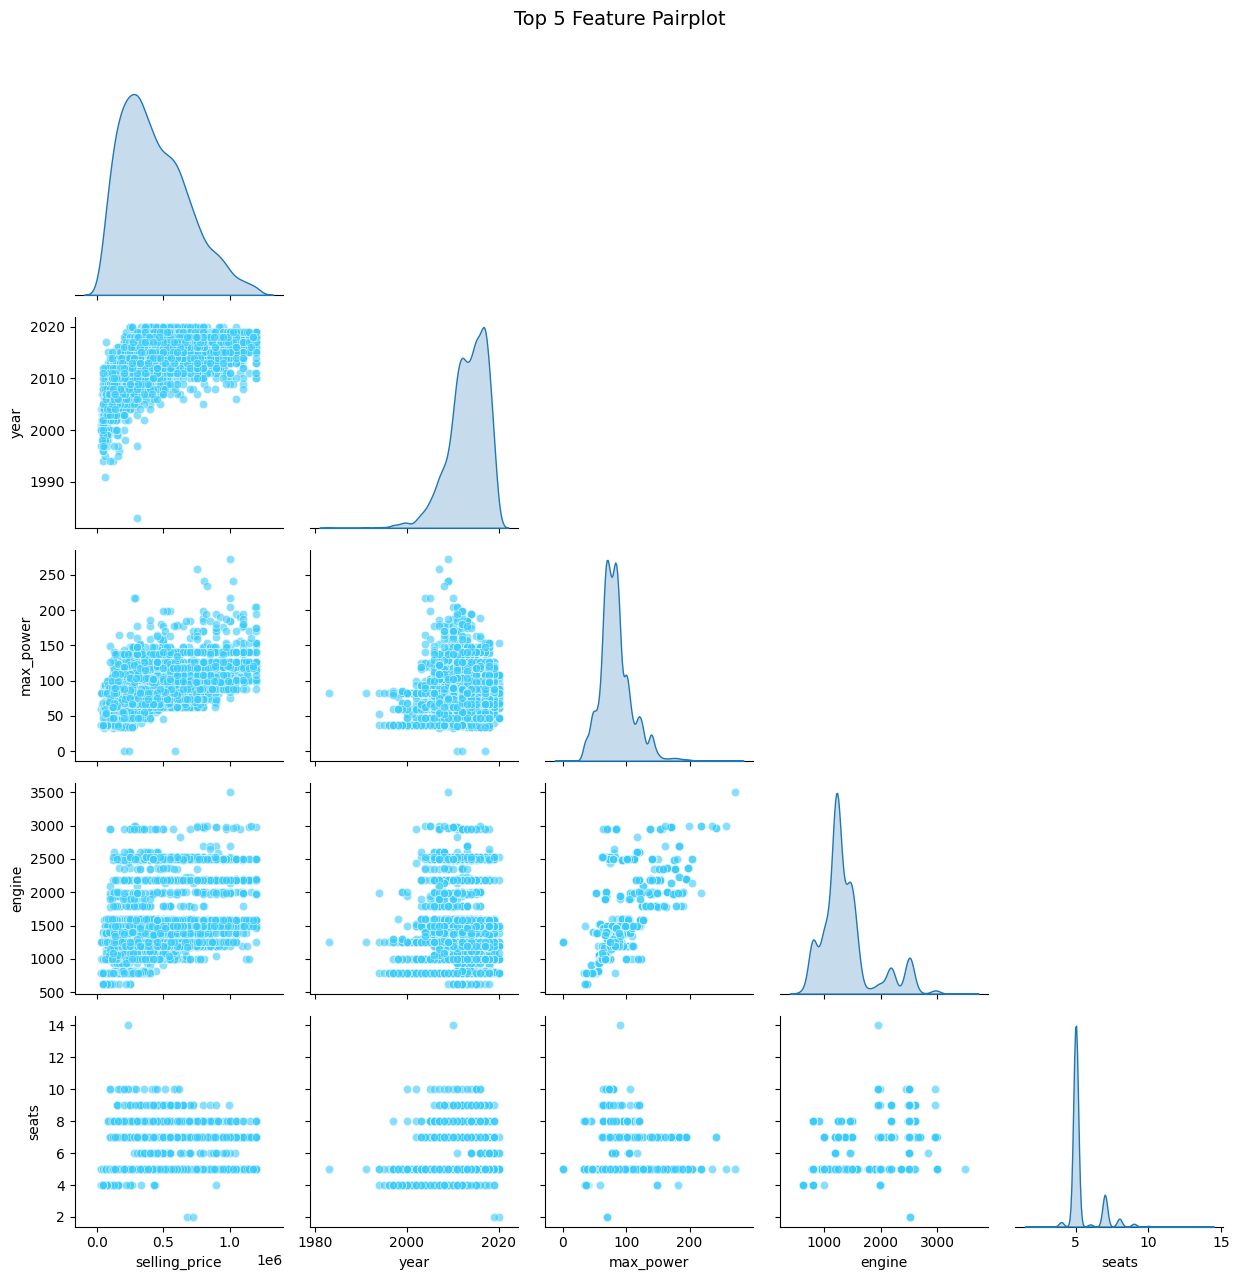

In [ ]:
top5 = ['selling_price','year','max_power','engine','seats']

sns.pairplot(
    df[top5],
    diag_kind='kde',
    plot_kws={'alpha':0.6, 'color':'#38cbfc'},
    corner=True
)
plt.suptitle('Top 5 Feature Pairplot', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

The `pairplot` displays pairwise relationships among the most important numerical variables. It helps identify correlations, clusters, and potential patterns within the dataset.

##Feature vs Target Relationships

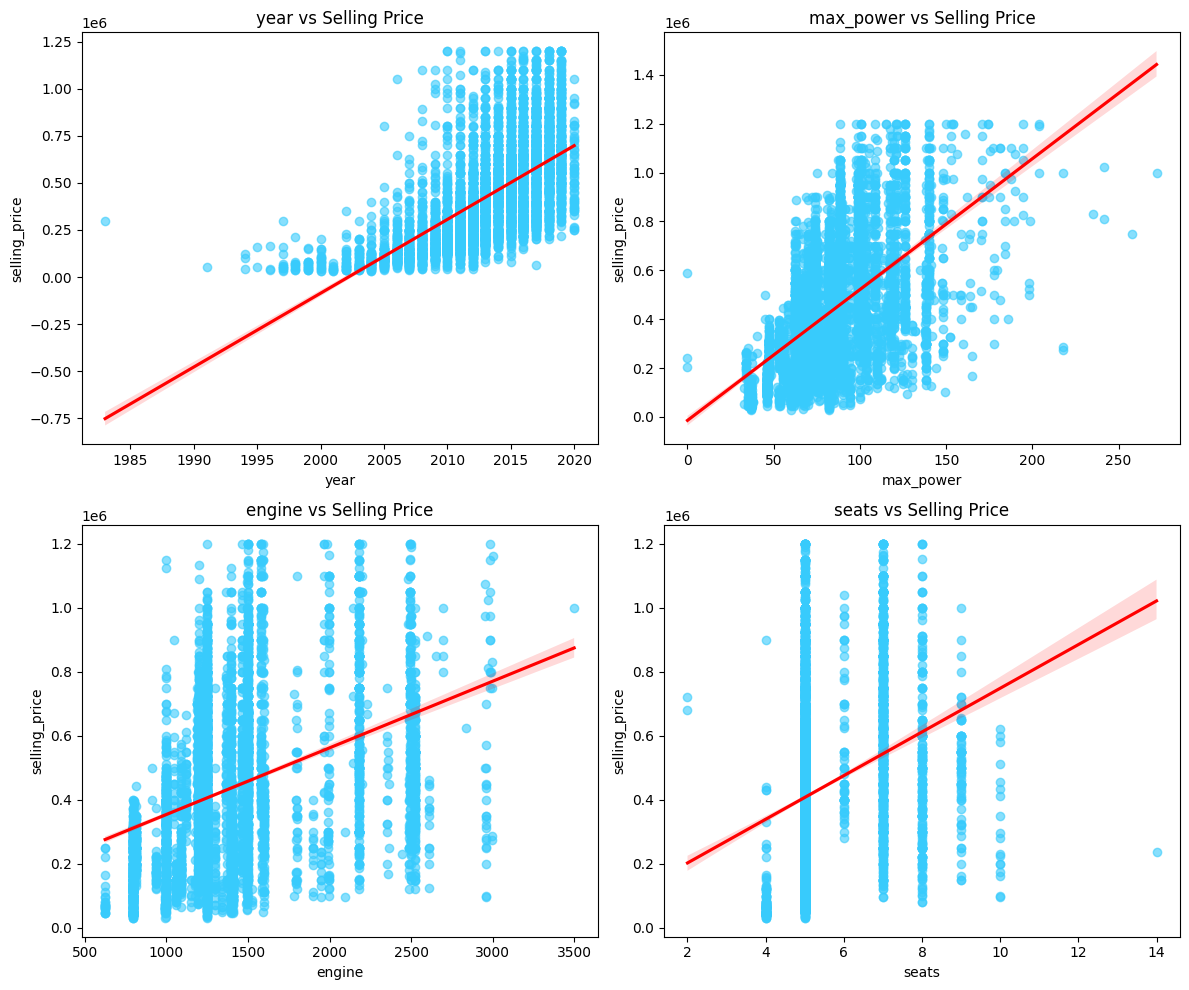

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))


pairs = [
    ('year',   'selling_price'),
    ('max_power', 'selling_price'),
    ('engine',  'selling_price'),
    ('seats',   'selling_price'),
]

for ax, (x_col, y_col) in zip(axes.flatten(), pairs):
    sns.regplot(
        data=df, x=x_col, y=y_col, ax=ax,
        scatter_kws={'alpha':0.6,'color':'#38cbfc'},
        line_kws={'color':'red'}
    )

    ax.set_title(f'{x_col} vs Selling Price')

plt.tight_layout()
plt.show()

Regression plots compare key vehicle characteristics such as year, engine size, max power, and seats against selling price. These visualizations help determine which features have the strongest influence on vehicle valuation.